# 🚀 Practice Day 13

**📅 Date:** 2026-09-24  
**📁 Category:** Phase 4 · 캡스톤 1 - 고객 세분화 RFM (Round 1/3)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Turn raw transactions into per-customer Recency / Frequency / Monetary metrics (거래 원본 데이터를 고객별 R/F/M 지표로 변환)
- Score and segment customers - this time, design the segmentation logic yourself (고객을 점수화·세분화 — 이번엔 세그먼트 기준 자체를 직접 설계)
- Capstone file: fewer hints than usual, more of the design is up to you (캡스톤 파일: 평소보다 힌트가 적고, 설계 자체를 더 많이 직접 결정)

---
# 📂 Dataset

**Dataset Name:** E-commerce Purchase History (이커머스 구매 이력)

**Source:** Synthetically generated for practice, fixed random seed (연습용으로 코드에서 직접 생성, seed 고정)

**Description:** Transaction-level purchase history: 267 orders from 46 customers (customer_id, order_id, order_date, amount). Customers vary a lot in how recently, how often, and how much they buy - some are recent/frequent/high-spend, others bought once a long time ago. Unlike earlier files, no segment label is given anywhere - that's what you're building.
(거래 단위 구매 이력 — 고객 46명, 총 주문 267건 (customer_id, order_id, order_date, amount). 고객마다 구매 최근성·빈도·금액대가 크게 다릅니다 — 최근에 자주, 많이 사는 고객도 있고 오래전에 한 번 사고 끝인 고객도 있습니다. 지금까지 파일들과 달리 세그먼트 라벨은 어디에도 주어지지 않습니다 — 그걸 직접 만드는 게 이번 과제입니다.)

## Dataset Preview

In [30]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)

REFERENCE_DATE = pd.Timestamp('2026-07-15')  # use this as "today" for any recency calculations

# 5 underlying customer archetypes drive the data (not stored as a column - the point
# of this file is to rediscover structure like this yourself via RFM)
archetypes = [
    # (weight, n_orders_range, days_since_last_order_range, order_amount_range)
    (0.15, (8, 15),  (0, 20),    (80000, 200000)),
    (0.25, (5, 10),  (10, 45),   (40000, 100000)),
    (0.20, (4, 8),   (60, 150),  (50000, 150000)),
    (0.25, (1, 3),   (0, 60),    (20000, 80000)),
    (0.15, (1, 3),   (100, 250), (15000, 50000)),
]

n_customers = 46
weights = [a[0] for a in archetypes]
customer_archetype = np.random.choice(len(archetypes), size=n_customers, p=weights)

rows = []
order_counter = 1
for cust_idx in range(n_customers):
    _, n_range, recency_range, amount_range = archetypes[customer_archetype[cust_idx]]
    n_orders = np.random.randint(n_range[0], n_range[1] + 1)
    last_order_recency = np.random.randint(recency_range[0], recency_range[1] + 1)
    last_order_date = REFERENCE_DATE - pd.Timedelta(days=int(last_order_recency))

    if n_orders == 1:
        order_dates = [last_order_date]
    else:
        span_days = np.random.randint(30, 300)
        earlier_offsets = sorted(np.random.choice(range(1, span_days + 1), size=n_orders - 1, replace=False), reverse=True)
        order_dates = [last_order_date - pd.Timedelta(days=int(d)) for d in earlier_offsets] + [last_order_date]

    for od in order_dates:
        amount = int(np.random.uniform(*amount_range))
        rows.append({
            'customer_id': f'CUST-{cust_idx+1:03d}',
            'order_id': f'ORD-{order_counter:05d}',
            'order_date': od,
            'amount': amount,
        })
        order_counter += 1

df = pd.DataFrame(rows)
df = df.sort_values('order_date').reset_index(drop=True)
df.head()

,customer_id,order_id,order_date,amount
0,CUST-028,ORD-00157,2025-09-22,116168
1,CUST-015,ORD-00070,2025-10-07,55183
2,CUST-009,ORD-00042,2025-10-16,75463
3,CUST-028,ORD-00158,2025-10-19,98398
4,CUST-011,ORD-00047,2025-10-21,166304


## Dataset Information

In [31]:
# Dataset Information
print(df.shape)
print('unique customers:', df['customer_id'].nunique())
df.info()
df.describe()

(267, 4)
unique customers: 46
<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  267 non-null    str           
 1   order_id     267 non-null    str           
 2   order_date   267 non-null    datetime64[us]
 3   amount       267 non-null    int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 8.5 KB


,order_date,amount
count,267,267.000000
mean,2026-03-29 16:59:19.550561,95602.543071
min,2025-09-22 00:00:00,16213.000000
25%,2026-02-02 00:00:00,66055.000000
50%,2026-04-16 00:00:00,88663.000000
75%,2026-05-28 12:00:00,125821.500000
max,2026-07-15 00:00:00,199560.000000
std,NaN,42939.971929


---
# ❓ Business Questions

1. For each customer, what are Recency (days since last order, using 2026-07-15 as "today"), Frequency (number of orders), and Monetary (total amount spent)? (고객별 Recency(2026-07-15 기준 마지막 주문 이후 경과일), Frequency(주문 건수), Monetary(총 구매액)은?)
2. Using quartile-based scoring, what R, F, and M score (1-4) does each customer get? (분위수 기준으로 고객별 R/F/M 점수(각 1~4점)는?)
3. Based on the combined RFM scores, how many customers fall into each segment you define (e.g., Champions, Loyal, At Risk, Lost)? (RFM 점수를 종합해서 직접 정의한 세그먼트(예: Champions, Loyal, At Risk, Lost)별 고객 수는?)
4. How are customers distributed across the segments you defined? (직접 정의한 세그먼트별 고객 분포는 어떤 모습인가?)
5. How do Recency and Monetary relate to each other across customers, viewed by segment? (고객별 Recency와 Monetary의 관계를 세그먼트별로 보면 어떤 모습인가?)

---
# 🛠 Skills Used
- [x] Python
- [x] NumPy — `np.select`
  (조건별로 세그먼트 이름 부여)
- [x] Pandas — `groupby().agg()`, `pd.qcut`, `value_counts`
  (고객별 R/F/M 집계, 분위수 점수, 세그먼트별 고객 수)
- [ ] SQL
- [x] Matplotlib — `plt.subplots`, `ax.bar`
  (막대 차트)
- [x] Other: Seaborn — `sns.scatterplot(hue=...)`
  (세그먼트별 색상 산점도) 

---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — 0
  (결측 없음)
- [x] Duplicate Rows — 0
  (중복 행 없음)
- [x] Wrong Data Types — `order_date` is datetime, `amount` is int; no fix needed
  (order_date는 datetime, amount는 정수. 수정 불필요)
- [ ] Rename Columns — not needed
  (불필요)
- [ ] Drop Columns — not needed
  (불필요)


In [32]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes")
print(df.dtypes)

print("\nColumn names")
print(df.columns.tolist())

obj_cols = df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(df[obj_cols].nunique())


Missing values
customer_id    0
order_id       0
order_date     0
amount         0
dtype: int64

Duplicate rows: 0

Dtypes
customer_id               str
order_id                  str
order_date     datetime64[us]
amount                  int64
dtype: object

Column names
['customer_id', 'order_id', 'order_date', 'amount']

Text columns — unique counts
customer_id     46
order_id       267
dtype: int64


---
# 📊 Analysis

## Question 1

**Question:** For each customer, what are Recency (days since last order, using 2026-07-15 as "today"), Frequency (number of orders), and Monetary (total amount spent)? (고객별 Recency(2026-07-15 기준 마지막 주문 이후 경과일), Frequency(주문 건수), Monetary(총 구매액)은?)

**Result:** The table has **46** customers. Recency ranges from **0** to **219** days, Frequency from **1** to **13** orders, and Monetary from **29,892** to **1,864,092**.
(표에는 고객 46명. Recency는 0~219일, Frequency는 1~13회, Monetary는 29,892~1,864,092)

**Insight:** Customers differ a lot on all three metrics, from someone who ordered today to someone who has not ordered for 219 days.
(세 지표 모두 고객마다 크게 다름. 오늘 주문한 고객부터 219일째 주문 없는 고객까지)

In [33]:
# Question 1: Build a customer-level RFM table from the transaction-level df
# Recency, Frequency, Monetary per customer_id. Reference date: 2026-07-15.

data1 = df.groupby('customer_id').agg(
    recency=('order_date', lambda x: (REFERENCE_DATE - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('amount', 'sum')
).reset_index().sort_values('recency')

display(data1)

,customer_id,recency,frequency,monetary
40,CUST-041,0,10,1480765
42,CUST-043,1,10,1618118
10,CUST-011,7,13,1864092
32,CUST-033,9,8,978893
29,CUST-030,9,8,1177358
16,CUST-017,11,6,442419
6,CUST-007,14,11,1281949
0,CUST-001,15,6,471590
37,CUST-038,18,11,1576256
5,CUST-006,19,5,338022


## Question 2

**Question:** Using quartile-based scoring, what R, F, and M score (1-4) does each customer get? (분위수 기준으로 고객별 R/F/M 점수(각 1~4점)는?)

**Result:** Every customer gets an R, F, and M score from **1** to **4**. Recency is reversed, so **4** means the most recent. For example, CUST-041, CUST-043, and CUST-011 score **4** on all three.
(모든 고객에게 R, F, M 점수 1~4점 부여. Recency는 반대로 매겨 4점이 가장 최근. 예: CUST-041, CUST-043, CUST-011은 세 점수 모두 4점)

**Insight:** The scores turn three different scales (days, orders, amount) into the same 1 to 4 scale. Customers with the same value fall into the same group, so the groups are not exactly equal in size.
(일수, 주문 수, 금액이라는 서로 다른 단위를 같은 1~4 점수로 바꿈. 같은 값은 같은 그룹에 들어가서 그룹 크기가 정확히 같지는 않음)

In [34]:
# Question 2: Score R, F, M into quartiles (1-4 each). Careful with direction - for Recency,
# a SMALLER number of days should be the BETTER (higher) score.

data1['R'] = pd.qcut(data1['recency'], q=4, labels=[4,3,2,1]).astype(int)
data1['F'] = pd.qcut(data1['frequency'], q=4, labels=[1,2,3,4]).astype(int)
data1['M'] = pd.qcut(data1['monetary'], q=4, labels=[1,2,3,4]).astype(int)

display(data1)

,customer_id,recency,frequency,monetary,R,F,M
40,CUST-041,0,10,1480765,4,4,4
42,CUST-043,1,10,1618118,4,4,4
10,CUST-011,7,13,1864092,4,4,4
32,CUST-033,9,8,978893,4,3,4
29,CUST-030,9,8,1177358,4,3,4
16,CUST-017,11,6,442419,4,3,2
6,CUST-007,14,11,1281949,4,4,4
0,CUST-001,15,6,471590,4,3,3
37,CUST-038,18,11,1576256,4,4,4
5,CUST-006,19,5,338022,4,2,2


## Question 3

**Question:** Based on the combined RFM scores, how many customers fall into each segment you define (e.g., Champions, Loyal, At Risk, Lost)? (RFM 점수를 종합해서 직접 정의한 세그먼트별 고객 수는?)

**Result:** Lost **17**, Champions **10**, Loyal **7**, New **6**, At Risk **6**. The total is **46**, and no customer is left as Unknown.
(Lost 17, Champions 10, Loyal 7, New 6, At Risk 6. 합계 46명, Unknown 없음)

**Insight:** Lost is the largest segment. Champions and Loyal together are **17** customers, and At Risk and Lost together are **23**.
(Lost가 가장 큰 세그먼트. Champions와 Loyal을 합치면 17명, At Risk와 Lost를 합치면 23명)

In [35]:
# Question 3: Design your own rule for turning R/F/M scores into a handful of named segments,
# then count how many customers land in each one.

conditions = [
    (data1['R'] == 4) & (data1['F'] > 2),  # Champions: very recent, frequent
    (data1['R'] == 3) & (data1['F'] > 2),  # Loyal: fairly recent, frequent
    (data1['R'] < 3) & (data1['F'] > 2),   # At Risk: used to buy often, gone quiet
    (data1['R'] > 2) & (data1['F'] < 3),   # New: recent, few orders
    (data1['R'] < 3) & (data1['F'] < 3),   # Lost: not recent, few orders
]
names = ['Champions', 'Loyal', 'At Risk', 'New', 'Lost']

data1['segment'] = np.select(conditions, names, default='Unknown')

data1['segment'].value_counts()

segment
Lost         17
Champions    10
Loyal         7
New           6
At Risk       6
Name: count, dtype: int64

---
# 📈 Visualization

**Chart 1:** Customer count by segment (bar chart) — 세그먼트별 고객 수

*Interpretation:* Bars are sorted from high to low. Lost is the tallest (**17**), then Champions (**10**), Loyal (**7**), and New and At Risk (**6** each).
(높은 순으로 정렬. Lost가 가장 높고(17), Champions(10), Loyal(7), New와 At Risk는 각각 6)

---

**Chart 2:** Recency vs. Monetary, colored by segment (scatter plot) — Recency vs Monetary 산점도 (세그먼트별 색상)

*Interpretation:* Champions are mostly in the upper left (low Recency, high Monetary), and Lost is mostly in the lower right (high Recency, low Monetary). At Risk is in the middle on both axes. New is low on both axes. Loyal is low on x and in the middle on y. Two Champions sit in the same area as Loyal.
(Champions는 대부분 왼쪽 위(Recency 낮고 Monetary 높음), Lost는 대부분 오른쪽 아래(Recency 높고 Monetary 낮음). At Risk는 x, y 모두 중간. New는 x, y 모두 낮음. Loyal은 x는 낮고 y는 중간. Champions 2명이 Loyal과 같은 위치에 있음)

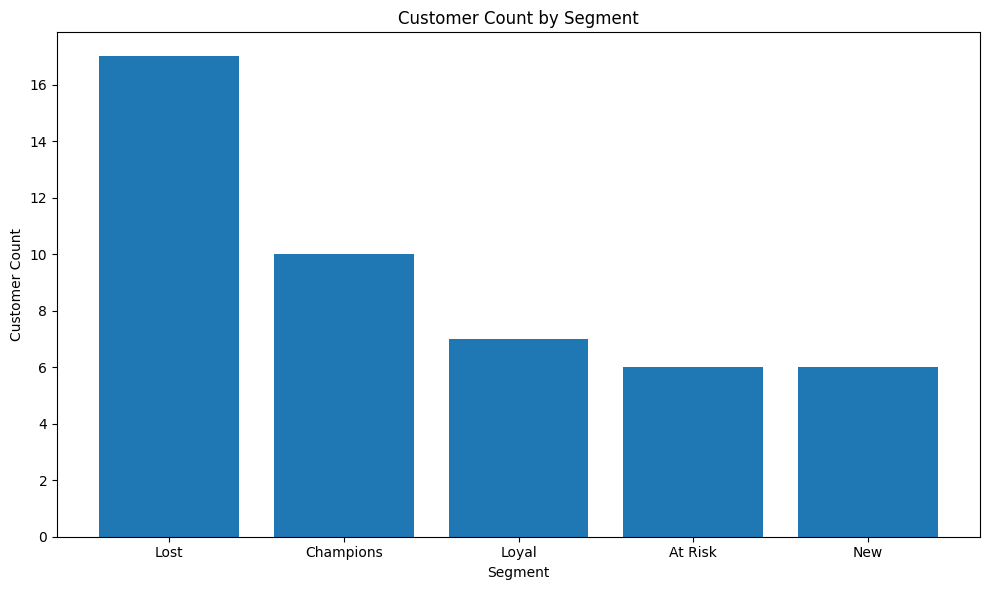

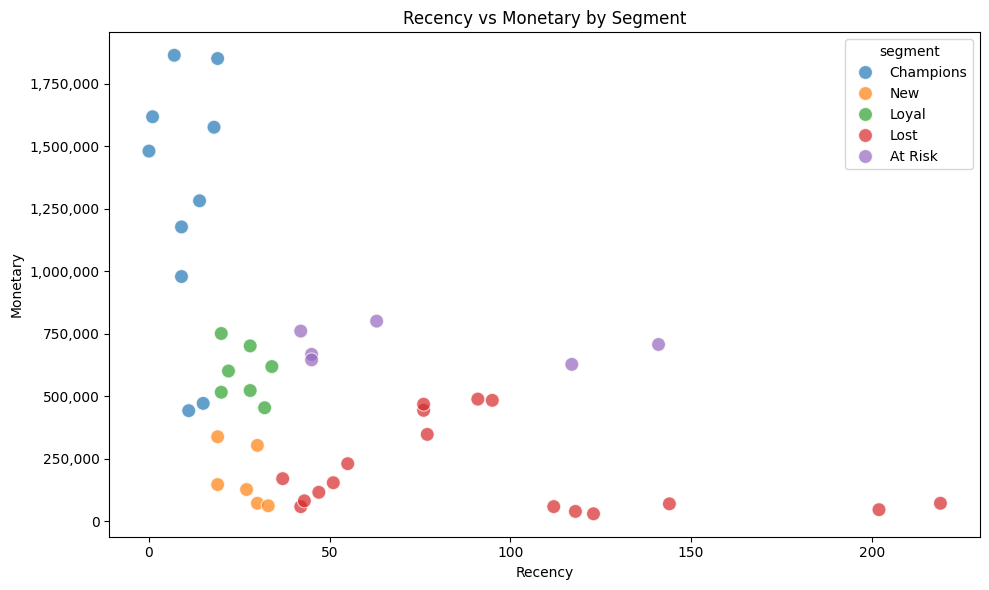

In [36]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: Customer count by segment (bar chart)
chart1 = data1.groupby('segment')['customer_id'].size().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(chart1.index, chart1.values)
ax.set_title('Customer Count by Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Customer Count')
plt.tight_layout()
plt.show()

# Chart 2: Recency (x) vs Monetary (y) scatter, one color per segment
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='recency', y='monetary', hue='segment', data=data1, ax=ax, s=100, alpha=0.7, edgecolor='white')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:,.0f}')
ax.set_title('Recency vs Monetary by Segment')
ax.set_xlabel('Recency')
ax.set_ylabel('Monetary')
plt.tight_layout()
plt.show()


---
# 💼 Business Insights
**What did I discover?**

- Lost is the largest segment (**17** of **46**). Champions and Loyal together are **17**, and At Risk and Lost together are **23**.
  (Lost가 46명 중 17명으로 가장 크고, Champions+Loyal은 17명, At Risk+Lost는 23명)
- On the scatter plot, Champions are in the upper left and Lost is in the lower right, so the segments match Recency and Monetary.
  (산점도에서 Champions는 왼쪽 위, Lost는 오른쪽 아래라 세그먼트가 Recency·Monetary와 맞아떨어짐)
- Two Champions sit in the same area as Loyal, because the segment rule uses R and F only, not M.
  (Champions 2명이 Loyal과 같은 위치. 세그먼트 규칙이 R, F만 쓰고 M은 쓰지 않기 때문)
  

---
# 🎯 Business Recommendation
**If I were the Business Analyst...**

1. Try to win back At Risk (**6**) first. They used to buy often, and they are a small group.
   (At Risk 6명부터 되찾기. 예전에 자주 사던 고객이고 규모도 작음)
2. Keep Champions and Loyal (**17** together) happy, since they are the active core.
   (Champions와 Loyal(합계 17명)은 현재의 핵심 고객이라 유지)
3. Add M to the segment rule, so the Champions that sit in the Loyal area are handled correctly. Use low-cost outreach for Lost (**17**).
   (세그먼트 규칙에 M을 추가해 Loyal 위치의 Champions를 바르게 분류. Lost(17명)는 비용이 적게 드는 방법으로 접근)
   

---
# ❌ Mistakes
**What mistakes did I make today?**

- I forgot the commas between the conditions in the list, which would raise `TypeError: 'Series' object is not callable`.
  (조건 리스트에서 조건 사이 쉼표를 빼먹음. TypeError가 남)
- The first rule let a customer match two segments (R = 2 and a high F matched both Loyal and At Risk). Rules should not overlap.
  (첫 규칙은 한 고객이 두 세그먼트에 맞았음(R=2, F 높음이 Loyal과 At Risk 둘 다). 규칙은 겹치면 안 됨)
- The scatter plot had a `1e6` y-axis and tiny dots until I set a formatter and `s=100`.
  (산점도에 y축 1e6 표시와 작은 점이 있었음. formatter와 s=100으로 해결)
  

---
# ✅ What I Learned
**Today's biggest lesson**

- `pd.qcut(col, q=4, labels=[...])` splits customers into quartile scores. For Recency, reverse the labels (`[4,3,2,1]`) because a smaller number of days is better.
  (qcut으로 분위수 점수를 만든다. Recency는 일수가 작을수록 좋아서 labels를 거꾸로 줌)
- `np.select(conditions, names, default=...)` turns rules into segment names. The first matching rule wins, so make rules that do not overlap, and use `default` as a check.
  (np.select는 규칙을 세그먼트 이름으로 바꾼다. 먼저 맞는 규칙이 이기므로 겹치지 않게 쓰고 default는 확인용)
- RFM is Recency (how recent), Frequency (how often), and Monetary (how much). R and F tell if a customer is still active and loyal.
  (RFM은 Recency(얼마나 최근), Frequency(얼마나 자주), Monetary(얼마나 많이). R과 F로 현재 활동 중인지, 충성인지 본다)
  

---
# 🧠 Reflection

**What was difficult?**
Deciding the segment rules myself.
(세그먼트 규칙을 직접 정하는 것)

**Why?**
There is no single right answer, and I did not know the usual RFM segments.
(정답이 하나가 아니고, 흔히 쓰는 RFM 세그먼트를 몰랐음)

**How did I solve it?**
Started from the standard Champions, Loyal, At Risk, New, and Lost, then split the R values so no rule overlaps.
(표준 세그먼트 5개로 시작해, 규칙이 겹치지 않게 R 값을 나눔)

**What would I do differently next time?**
Check for overlap between rules before running. Decide whether M belongs in the rule.
(실행 전에 규칙 간 겹침부터 확인. M을 규칙에 넣을지 결정)



---
# ⭐ Self Evaluation

**Understanding**
★★★★★★☆☆☆☆
(RFM 계산과 점수는 이해. 세그먼트 규칙 설계는 도움 필요)

**Confidence**
★★★★★☆☆☆☆☆

**Difficulty**
★★★★★★★☆☆☆
(규칙을 직접 정하는 것이 어려웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 14 — capstone 2: customer churn
  (캡스톤 2: 고객 이탈)
  